# Spectral fitting example (NGC 4151)

This notebook fits the NGC 4151 mock data with a single, explicitly
constructed point-source model. It does not load a source catalog: the fitted
model contains NGC 4151 only, using the same cutoff-power-law plus power-law
tail form as the injected spectrum. This follows the direct-model workflow
used in the Crab spectral-fit tutorial.


In [1]:
from pathlib import Path
import sys

import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

from astromodels import Cutoff_powerlaw, Parameter, Powerlaw
from histpy import Histogram
from threeML import DataList, JointLikelihood, Model, PointSource

from cosipy import BinnedData
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.data_io import EmCDSBinnedData
from cosipy.event_selection import GoodTimeInterval
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import (
    BinnedInstrumentResponse,
    BinnedThreeMLModelFolding,
    BinnedThreeMLPointSourceResponse,
)
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.statistics import PoissonLikelihood

%matplotlib inline


18:52:53 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=410566;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=59555;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=354066;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=266523;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

18:52:54 WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=813759;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=186575;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

18:52:54 INFO      Starting 3ML!                                                                     ]8;id=957644;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=381848;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=502525;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=79013;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

18:52:55 WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=272467;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=828915;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=758261;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=675605;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=786579;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=611368;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=595895;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=215479;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=762765;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=898597;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

## Load the FOV-cut data and response

The mock-data and background files below were binned after applying the same 60° NGC 4151 pointing cut used for the spacecraft history.

In [2]:
notebook_dir = Path(
    "/Users/parshadkp/Software/cosipy/docs/tutorials/spectral_fits/continuum_fit/AGN"
)
mock_data_path = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/"
    "DC4_Files/Mock_Data/Mock_Data_Cut/"
    "mock_with_updated_NGC4151_FluxNTH_0p30_time_cut.hdf5"
)
background_path = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/"
    "DC4_Files/Background/"
    "Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_"
    "NGC4151_60deg_fov_cut.hdf5"
)
orientation_path = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/"
    "DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori"
)
response_path = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/"
    "DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491."
    "m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"
)
agn_config = notebook_dir / "agn.yaml"

# Scale counts and response livetime together, without changing source flux.
exposure_multiplier = 1
exposure_months = 3 * exposure_multiplier

for path in (
    mock_data_path,
    background_path,
    orientation_path,
    response_path,
    agn_config,
):
    if not path.exists():
        raise FileNotFoundError(path)


Apply the 60° orientation/FOV cut for NGC 4151, including Earth
occultation. The resulting history is used for both the background model and
the single NGC 4151 point-source response.


In [3]:
source_l = 155.07 * u.deg
source_b = 75.06 * u.deg
source_coord = SkyCoord(l=source_l, b=source_b, frame="galactic")

max_offaxis = 60 * u.deg
earth_occ = True

sc_orientation_full = SpacecraftHistory.open(orientation_path)
source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord,
    sc_orientation_full,
    max_offaxis,
    earth_occ=earth_occ,
)
sc_orientation_cut = sc_orientation_full.apply_gti(source_gti)

# Repeat the selected pointing history by scaling its interval livetimes.
sc_orientation = SpacecraftHistory(
    sc_orientation_cut.obstime,
    sc_orientation_cut.attitude,
    sc_orientation_cut.location,
    livetime=sc_orientation_cut.livetime * exposure_multiplier,
)
sc_orientation.cache_earth_occ = sc_orientation_cut.cache_earth_occ

full_livetime = sc_orientation_full.cumulative_livetime().to_value(u.s)
fov_livetime = sc_orientation_cut.cumulative_livetime().to_value(u.s)
scaled_livetime = sc_orientation.cumulative_livetime().to_value(u.s)
print(f"Full orientation livetime: {full_livetime:,.1f} s")
print(f"Three-month FOV-cut livetime: {fov_livetime:,.1f} s")
print(f"Scaled {exposure_months}-month livetime: {scaled_livetime:,.1f} s")
print(f"FOV/full livetime fraction: {fov_livetime / full_livetime:.4f}")


Full orientation livetime: 6,579,555.0 s
Three-month FOV-cut livetime: 980,415.0 s
Scaled 3-month livetime: 980,415.0 s
FOV/full livetime fraction: 0.1490


Load the binned mock data and matching total-background template. `exposure_multiplier` scales the three-month source and background counts to 24 months. It does not change any intrinsic source-spectrum parameters.

In [4]:
mock_data = BinnedData(agn_config)
mock_data.load_binned_data_from_hdf5(binned_data=mock_data_path)

data_hist = mock_data.binned_data.project("Em", "Phi", "PsiChi")
data_hist *= exposure_multiplier

total_bkg = Histogram.open(background_path).project("Em", "Phi", "PsiChi")
total_bkg *= exposure_multiplier
total_bkg += sys.float_info.min
bkg_dist = {"total_bkg": total_bkg}

Open the continuum response.

In [5]:
dr = FullDetectorResponse.open(str(response_path))

## Perform the spectral fit

Create the COSI 3ML plugin using the FOV-cut history. There is one
standard point-source response because this fit models NGC 4151 directly and
does not include a source catalog or source-specific nuisance responses.


In [6]:
data = EmCDSBinnedData(data_hist)

bkg = FreeNormBinnedBackground(
    bkg_dist,
    sc_history=sc_orientation,
    copy=False,
)

instrument_response = BinnedInstrumentResponse(dr, data)
psr = BinnedThreeMLPointSourceResponse(
    data=data,
    instrument_response=instrument_response,
    sc_history=sc_orientation,
    energy_axis=dr.axes["Ei"],
    polarization_axis=dr.axes["Pol"] if "Pol" in dr.axes.labels else None,
    nside=2 * data.axes["PsiChi"].nside,
)
response = BinnedThreeMLModelFolding(data=data, point_source_response=psr)
like_fun = PoissonLikelihood(data, response, bkg)
cosi = ThreeMLPluginInterface("cosi", like_fun, response, bkg)

for bkg_label in bkg_dist:
    cosi.bkg_parameter[bkg_label] = Parameter(
        bkg_label,
        1.0,
        min_value=0.0,
        max_value=50.0,
        delta=0.05,
        unit=u.Hz,
    )


Construct a single NGC 4151 point source directly, as in the Crab
example. The fit frees the cutoff-power-law normalization and cutoff energy,
and the power-law-tail normalization and index. The pivots and the thermal
photon index are fixed to the injected values.


In [7]:
D = 0.30

# Injected spectrum, used only for comparison in the plot.
spectrum_inj_cpl = Cutoff_powerlaw()
spectrum_inj_cpl.K.value = 0.15
spectrum_inj_cpl.piv.value = 1.0
spectrum_inj_cpl.xc.value = 200.0
spectrum_inj_cpl.index.value = -1.75
spectrum_inj_cpl.K.unit = 1 / (u.cm**2 * u.s * u.keV)
spectrum_inj_cpl.piv.unit = u.keV
spectrum_inj_cpl.xc.unit = u.keV

spectrum_inj_tail = Powerlaw()
spectrum_inj_tail.K.value = D * spectrum_inj_cpl.evaluate_at(200.0)
spectrum_inj_tail.piv.value = 200.0
spectrum_inj_tail.index.value = -3.8
spectrum_inj_tail.K.unit = 1 / (u.cm**2 * u.s * u.keV)
spectrum_inj_tail.piv.unit = u.keV
spectrum_inj = spectrum_inj_cpl + spectrum_inj_tail

# Direct NGC 4151 fit model: Cutoff_powerlaw + Powerlaw.
spectrum = Cutoff_powerlaw() + Powerlaw()
spectrum.K_1.value = 1.41e-5
spectrum.K_1.min_value = 1e-8
spectrum.K_1.max_value = 1e-2
spectrum.K_1.unit = 1 / (u.cm**2 * u.s * u.keV)
spectrum.piv_1.value = 200.0
spectrum.piv_1.unit = u.keV
spectrum.index_1.value = -1.75
spectrum.index_1.fix = True
spectrum.xc_1.value = 200.0
spectrum.xc_1.min_value = 100.0
spectrum.xc_1.max_value = 10000.0
spectrum.xc_1.unit = u.keV

# At the common 200 keV pivot, the injected tail is D times the cutoff
# component evaluated at 200 keV, hence its initial ratio is D * exp(-1).
spectrum.K_2.value = D * np.exp(-1) * spectrum.K_1.value
spectrum.K_2.min_value = 1e-8
spectrum.K_2.max_value = 1e-2
spectrum.K_2.unit = 1 / (u.cm**2 * u.s * u.keV)
spectrum.piv_2.value = 200.0
spectrum.piv_2.unit = u.keV
spectrum.index_2.value = -3.8
spectrum.index_2.min_value = -5.0
spectrum.index_2.max_value = -2.0

spectrum.piv_1.fix = True
spectrum.piv_2.fix = True

source = PointSource(
    "ngc4151",
    l=source_l.to_value(u.deg),
    b=source_b.to_value(u.deg),
    spectral_shape=spectrum,
)
model = Model(source)

print("Model sources:", list(model.sources))
print("Free parameters:", list(model.free_parameters))


Model sources: ['ngc4151']
Free parameters: ['ngc4151.spectrum.main.composite.K_1', 'ngc4151.spectrum.main.composite.xc_1', 'ngc4151.spectrum.main.composite.K_2', 'ngc4151.spectrum.main.composite.index_2']


Fit the source model and background normalization once.

In [8]:
plugins = DataList(cosi)
like = JointLikelihood(model, plugins, verbose=False)
_ = like.fit()

18:53:05 INFO      set the minimizer to minuit                                             ]8;id=755390;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=343329;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

18:53:21 WARNING   49.58 percent of samples have been thrown away because they failed the  ]8;id=175986;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=200214;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

18:53:21 WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=819687;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=42849;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc_1 (10.0) was below the new minimum 100.0. ]8;id=723662;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=591705;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

         WARNING   The current value of the parameter K_2 (1.0) was above the new maximum 0.01.    ]8;id=64749;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=881008;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

...

1.00,-0.52,-0.39,0.04,-0.28
-0.52,1.00,-0.31,-0.00,-0.09
-0.39,-0.31,1.00,-0.06,-0.12
0.04,-0.00,-0.06,1.00,0.00
-0.28,-0.09,-0.12,0.00,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-118218916.40089929
total,-118218916.40089929


Values of statistical measures:

,statistical measures
AIC,-236437822.80153817
BIC,-236437771.06393754


## Error propagation and plotting

Propagate the fitted parameter uncertainties to the NGC 4151 spectrum.

In [9]:
results = like.results
print(results.display())

parameters = {
    parameter.name: results.get_variates(parameter.path)
    for parameter in results.optimized_model["ngc4151"].parameters.values()
    if parameter.free
}
results_err = results.propagate(
    results.optimized_model["ngc4151"].spectrum.main.shape.evaluate_at,
    **parameters,
)

print(results.optimized_model["ngc4151"])

Best fit values:

,result,unit
parameter,,
ngc4151.spectrum.main.composite.K_1,(1.74 +/- 0.10) x 10^-5,1 / (keV s cm2)
ngc4151.spectrum.main.composite.xc_1,(4.13 -0.27 +0.29) x 10^2,keV
ngc4151.spectrum.main.composite.K_2,(2.73 -0.33 +0.4) x 10^-6,1 / (keV s cm2)
ngc4151.spectrum.main.composite.index_2,-2.000000 +/- 0.000007,
total_bkg,(2.6520 +/- 0.0007) x 10,Hz


Correlation matrix:

1.00,-0.52,-0.39,0.04,-0.28
-0.52,1.00,-0.31,-0.00,-0.09
-0.39,-0.31,1.00,-0.06,-0.12
0.04,-0.00,-0.06,1.00,0.00
-0.28,-0.09,-0.12,0.00,1.00


Values of -log(likelihood) at the minimum:

...

         WARNING   The current value of the parameter K_2 (1.0) was above the new maximum 0.01.    ]8;id=81294;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=547082;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=531701;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=814950;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc_1 (10.0) was below the new minimum 100.0. ]8;id=754393;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=356268;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

         WARNING   The current value of the parameter K_2 (1.0) was above the new maximum 0.01.    ]8;id=902637;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=252471;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

  * ngc4151 (point source):
    * position:
      * l:
        * value: 155.07
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: 75.06
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * composite:
          * K_1:
            * value: 1.7432803304493347e-05
            * desc: Normalization (differential flux at the pivot value)
            * min_value: 1.0e-08
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * piv_1:
            * value: 200.0
            * desc: Pivot value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * index_1:
            * value: -1.75
            * 

Evaluate the fitted and injected spectra from 200 keV to 5 MeV.

In [10]:
energy = np.geomspace(200 * u.keV, 5 * u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj.evaluate_at(e)

binned_energy_edges = data_hist.axes["Em"].edges.to_value(u.keV)
binned_energy = 0.5 * (binned_energy_edges[1:] + binned_energy_edges[:-1])
expectation = response.expectation()

Plot the fitted and injected SED using the same style as `AGN_Corona_DC4_SubMethod.ipynb`.

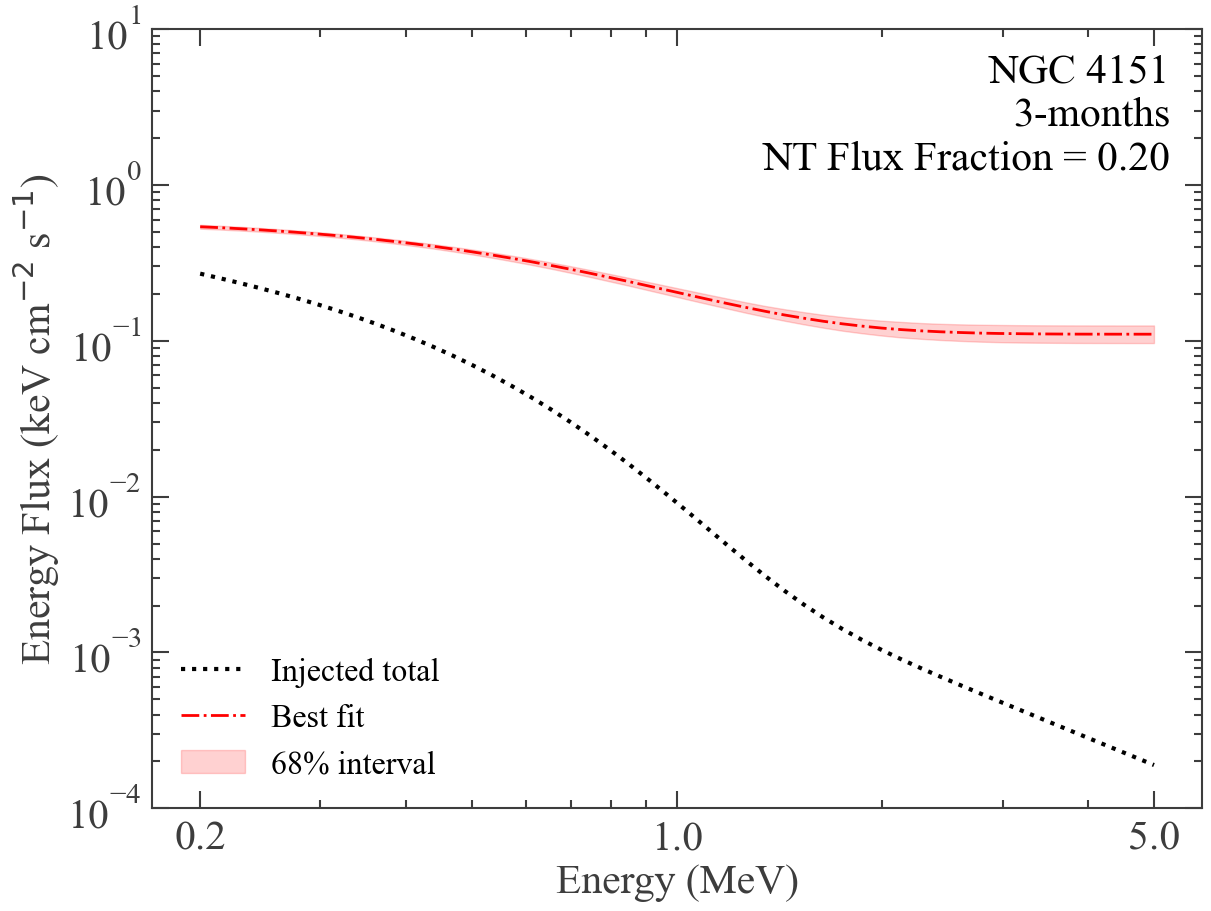

In [11]:
FONT_SIZE = 30
plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update({
    "font.weight": "550",
    "axes.titleweight": "550",
    "axes.labelweight": "550",
})


def style_axis(ax):
    ax.xaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", top=True, pad=8, labelsize=FONT_SIZE)
    ax.xaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", top=True, pad=8)
    ax.yaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", right=True, pad=8, labelsize=FONT_SIZE)
    ax.yaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", right=True, pad=8)
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)


fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)

ax.plot(
    energy / 1000,
    energy * energy * flux_inj,
    color="black",
    ls=":",
    lw=3,
    label="Injected total",
)
ax.plot(
    energy / 1000,
    energy * energy * flux_median,
    color="red",
    lw=2,
    linestyle="dashdot",
    label="Best fit",
)
ax.fill_between(
    energy / 1000,
    energy * energy * flux_lo,
    energy * energy * flux_hi,
    alpha=0.18,
    color="red",
    label="68% interval",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-4, 10)
ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))
ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

thermal_flux = np.asarray([spectrum_inj_cpl.evaluate_at(e) for e in energy])
tail_flux = np.asarray([spectrum_inj_tail.evaluate_at(e) for e in energy])
thermal_energy_flux = np.trapezoid(energy * thermal_flux, energy)
tail_energy_flux = np.trapezoid(energy * tail_flux, energy)
energy_flux_ratio = tail_energy_flux / (thermal_energy_flux + tail_energy_flux)

ax.text(
    0.97,
    0.97,
    f"NGC 4151\n{exposure_months}-months\nNT Flux Fraction = {energy_flux_ratio:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=FONT_SIZE,
    fontweight="550",
)
ax.legend(fontsize=23, loc="lower left", frameon=False)
plt.show()

Plot the fitted source plus background counts and the observed counts with the same publication-style formatting.

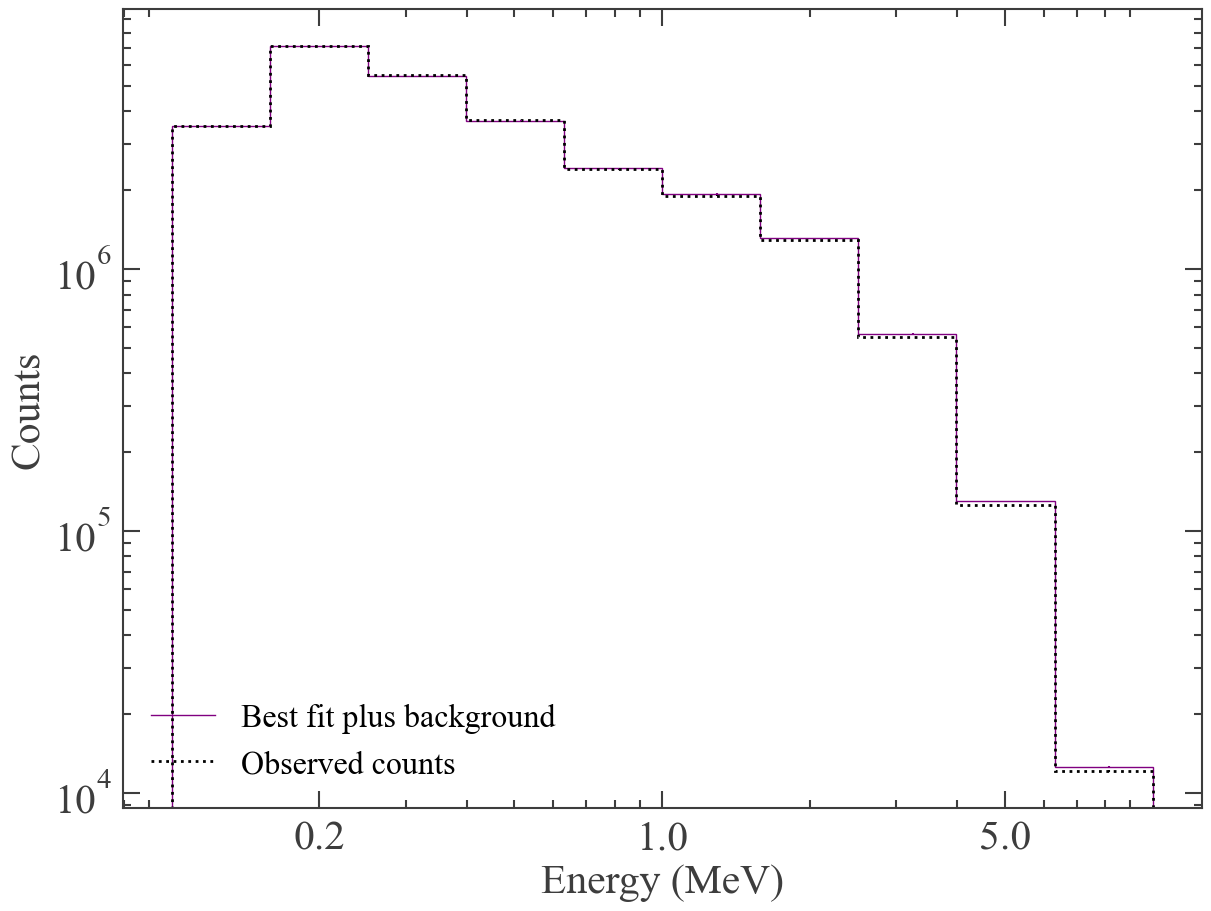

In [12]:
expectation_bkg = bkg.expectation(copy=True)
model_counts = (
    expectation.project("Em").to_dense(copy=False).contents
    + expectation_bkg.project("Em").to_dense(copy=False).contents
)
data_counts = data.data.project("Em").to_dense(copy=False).contents

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)

ax.stairs(
    model_counts,
    binned_energy_edges / 1000,
    color="purple",
    label="Best fit plus background",
)
ax.errorbar(
    binned_energy / 1000,
    model_counts,
    yerr=np.sqrt(model_counts),
    color="purple",
    linewidth=0,
    elinewidth=1.5,
)
ax.stairs(
    data_counts,
    binned_energy_edges / 1000,
    color="black",
    ls=":",
    lw=2,
    label="Observed counts",
)
ax.errorbar(
    binned_energy / 1000,
    data_counts,
    yerr=np.sqrt(data_counts),
    color="black",
    linewidth=0,
    elinewidth=1.5,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))
ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel("Counts", fontsize=FONT_SIZE)
ax.legend(fontsize=23, loc="lower left", frameon=False)
plt.show()